In [1]:
!nvidia-smi

Tue Aug 11 22:29:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!rm -rf /content/sequence-modelling

In [3]:
!git clone https://github.com/Dorcas-Joy-Kahunguka/sequence-modelling
%cd sequence-modelling/mechinterp-typoglycemia/

Cloning into 'sequence-modelling'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 148 (delta 49), reused 131 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 93.01 KiB | 6.20 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/sequence-modelling/mechinterp-typoglycemia


In [4]:
%pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.7 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=5608fb6ed57caebda8236a55a577a6da739d946ce7bdf57f8cccfe6f31f520b6
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


In [6]:
import transformer_lens
from transformer_lens import HookedTransformer

import sys
sys.path.append(".")

import threading
from concurrent.futures import ThreadPoolExecutor
from src.data_utils import load_json_dataset
from src import behavioural_utils as bu

import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

import torch
import json
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt





[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
CACHE_DIR = "/content/drive/MyDrive/typoglycemia_activations"

import os
os.makedirs(CACHE_DIR, exist_ok=True)

In [10]:
TOP_K = 5


@torch.no_grad()
def predict_next_word(model, sentence, top_k=TOP_K):
    """
    Run `model` on `sentence` and return the top-k predicted next tokens
    (decoded to strings, stripped) along with their probabilities, for the
    final token position.
    """
    tokens = model.to_tokens(sentence, prepend_bos=True)
    logits, cache = model.run_with_cache(tokens)
    last_logits = logits[0, -1]
    probs = torch.softmax(last_logits, dim=-1)
    top_probs, top_ids = probs.topk(top_k)
    words = [model.tokenizer.decode([tid]).strip() for tid in top_ids.tolist()]

    pred = {
            "top1": words[0],
            "top_k_words": words,
            "top_k_probs": top_probs.tolist(),
        }

    internals = {
        "tokens": tokens.cpu(),
        "str_tokens": model.to_str_tokens(sentence, prepend_bos=True),
        "logits": logits.cpu().half(),
        "cache": {k: v.cpu().half() for k, v in cache.items()},
    }

    return pred,internals 
    


def predict_pair(idx):
    """Run clean + scrambled prediction for one pair concurrently on two threads."""
    with ThreadPoolExecutor(max_workers=2) as executor:
        fut_clean = executor.submit(predict_next_word, model_clean, clean_sentences[idx])
        fut_scrambled = executor.submit(predict_next_word, model_scrambled, scrambled_sentences[idx])
        return fut_clean.result(), fut_scrambled.result()

In [11]:
MODEL_NAME = "gpt2-small"  
device = "cuda" if torch.cuda.is_available() else "cpu"

model_clean = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model_scrambled = HookedTransformer.from_pretrained(MODEL_NAME, device=device)

model_clean.eval()
model_scrambled.eval()
print("Loaded two model instances on", device)



/tmp/ipykernel_2189/4131083537.py:4: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model_clean = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


/tmp/ipykernel_2189/4131083537.py:5: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model_scrambled = HookedTransformer.from_pretrained(MODEL_NAME, device=device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded two model instances on cuda


In [ ]:
with open("/content/drive/MyDrive/typoglycemia_activations/bos_token.json", "w") as f: 
    json.dump({"bos_token": model_clean.tokenizer.bos_token}, f) 
print(f"Saved bos_token.json: {model_clean.tokenizer.bos_token!r}")

#files.download("bos_token.json")

Saved bos_token.json: '<|endoftext|>'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
ids, clean_sentences, scrambled_sentences, target_words = load_json_dataset("data/processed/clean.json", "data/processed/scramble.json","data/processed/target.json")
print("ids", ids)
print("clean_sentences", clean_sentences)
print("scrambled_sentences", scrambled_sentences)
print("target_words", target_words)

ids ['0', '1', '2', '3', '4']
clean_sentences ["I'm building my first ever company this", 'Maria can drink Java dawa even on a hot', 'Who tried to bribe the policemen and the', 'Dr. Wang won the', 'A well-known baker came up with the']
scrambled_sentences ["I'm bdiinlug my frist eevr cnpaomy tihs", 'Miraa can dnirk Jvaa dwaa eevn on a hot', 'Who treid to bibre the piocelmen and the', 'Dr. Wnag won the', 'A wowkl-nlen beakr cmae up wtih the']
target_words ['year', 'day', 'judge', 'grant', 'idea']


In [18]:
records = []
for i in range(len(ids)):
    (clean_pred, clean_internals), (scrambled_pred, scrambled_internals) = predict_pair(i)

    cache_path = f"{CACHE_DIR}/{ids[i]}.pt"

    torch.save({
    "id": ids[i],
    "clean_sentence": clean_sentences[i],
    "scrambled_sentence": scrambled_sentences[i],
    "clean": clean_internals,
    "scrambled": scrambled_internals,
    },
    cache_path,)

    records.append({
        "id": ids[i],
        "clean_sentence": clean_sentences[i],
        "scrambled_sentence": scrambled_sentences[i],
        "target_word": target_words[i],
        "clean_top1": clean_pred["top1"],
        "clean_top_k": clean_pred["top_k_words"],
        "scrambled_top1": scrambled_pred["top1"],
        "scrambled_top_k": scrambled_pred["top_k_words"],
        "cache_path": cache_path,
    })
    if (i + 1) % 25 == 0:
        print(f"{i + 1}/{len(ids)} pairs done")

print("Done:", len(records), "pairs predicted.")
print(records)

Done: 5 pairs predicted.
[{'id': '0', 'clean_sentence': "I'm building my first ever company this", 'scrambled_sentence': "I'm bdiinlug my frist eevr cnpaomy tihs", 'target_word': 'year', 'clean_top1': 'year', 'clean_top_k': ['year', 'week', 'summer', 'month', 'fall'], 'scrambled_top1': '.', 'scrambled_top_k': ['.', 't', ',', 'e', 'n'], 'cache_path': '/content/drive/MyDrive/typoglycemia_activations/0.pt'}, {'id': '1', 'clean_sentence': 'Maria can drink Java dawa even on a hot', 'scrambled_sentence': 'Miraa can dnirk Jvaa dwaa eevn on a hot', 'target_word': 'day', 'clean_top1': 'day', 'clean_top_k': ['day', 'summer', 'afternoon', 'morning', 'night'], 'scrambled_top1': 'day', 'scrambled_top_k': ['day', '-', 'bed', 'spot', 'd'], 'cache_path': '/content/drive/MyDrive/typoglycemia_activations/1.pt'}, {'id': '2', 'clean_sentence': 'Who tried to bribe the policemen and the', 'scrambled_sentence': 'Who treid to bibre the piocelmen and the', 'target_word': 'judge', 'clean_top1': 'police', 'clean

In [19]:
for r in records:
    r["pred_cosine_sim"] = bu.word_cosine_relatedness(model_clean, r["clean_top1"], r["scrambled_top1"])
    r["pred_wordnet_wup"] = bu.wordnet_relatedness(r["clean_top1"], r["scrambled_top1"], metric="wup")
    r["pred_wordnet_path"] = bu.wordnet_relatedness(r["clean_top1"], r["scrambled_top1"], metric="path")

print(records)

[{'id': '0', 'clean_sentence': "I'm building my first ever company this", 'scrambled_sentence': "I'm bdiinlug my frist eevr cnpaomy tihs", 'target_word': 'year', 'clean_top1': 'year', 'clean_top_k': ['year', 'week', 'summer', 'month', 'fall'], 'scrambled_top1': '.', 'scrambled_top_k': ['.', 't', ',', 'e', 'n'], 'cache_path': '/content/drive/MyDrive/typoglycemia_activations/0.pt', 'pred_cosine_sim': 0.22154246270656586, 'pred_wordnet_wup': None, 'pred_wordnet_path': None}, {'id': '1', 'clean_sentence': 'Maria can drink Java dawa even on a hot', 'scrambled_sentence': 'Miraa can dnirk Jvaa dwaa eevn on a hot', 'target_word': 'day', 'clean_top1': 'day', 'clean_top_k': ['day', 'summer', 'afternoon', 'morning', 'night'], 'scrambled_top1': 'day', 'scrambled_top_k': ['day', '-', 'bed', 'spot', 'd'], 'cache_path': '/content/drive/MyDrive/typoglycemia_activations/1.pt', 'pred_cosine_sim': 0.9999998807907104, 'pred_wordnet_wup': 1.0, 'pred_wordnet_path': 1.0}, {'id': '2', 'clean_sentence': 'Who t

In [20]:
for r in records:
    r["consistency_category"] = bu.classify_consistency(r["clean_top1"], r["scrambled_top1"],cosine_sim=r["pred_cosine_sim"], wordnet_sim=r["pred_wordnet_wup"])
print(bu.summarize_consistency(records))

{'unrelated': 3, 'identical': 2}


In [21]:

df = pd.DataFrame(records)

df.to_json("./data/processed/behavioural_evaluation_results.json", orient="records", indent=2)

df.to_csv("./data/processed/jsonbehavioural_evaluation_results.csv", index=False)
df.head()


,id,clean_sentence,scrambled_sentence,target_word,clean_top1,clean_top_k,scrambled_top1,scrambled_top_k,cache_path,pred_cosine_sim,pred_wordnet_wup,pred_wordnet_path,consistency_category
0,0,I'm building my first ever company this,I'm bdiinlug my frist eevr cnpaomy tihs,year,year,"[year, week, summer, month, fall]",.,"[., t, ,, e, n]",/content/drive/MyDrive/typoglycemia_activation...,0.221542,NaN,NaN,unrelated
1,1,Maria can drink Java dawa even on a hot,Miraa can dnirk Jvaa dwaa eevn on a hot,day,day,"[day, summer, afternoon, morning, night]",day,"[day, -, bed, spot, d]",/content/drive/MyDrive/typoglycemia_activation...,1.000000,1.000000,1.000000,identical
2,2,Who tried to bribe the policemen and the,Who treid to bibre the piocelmen and the,judge,police,"[police, cops, policemen, soldiers, army]",p,"[p, b, c, g, m]",/content/drive/MyDrive/typoglycemia_activation...,0.264868,0.285714,0.090909,unrelated
3,3,Dr. Wang won the,Dr. Wnag won the,grant,Nobel,"[Nobel, prestigious, 2015, 2014, 2016]",Nobel,"[Nobel, award, 2016, 2015, prestigious]",/content/drive/MyDrive/typoglycemia_activation...,1.000000,0.916667,1.000000,identical
4,4,A well-known baker came up with the,A wowkl-nlen beakr cmae up wtih the,idea,idea,"[idea, name, concept, recipe, perfect]",n,"[n, c, g, w, l]",/content/drive/MyDrive/typoglycemia_activation...,0.204118,0.307692,0.100000,unrelated


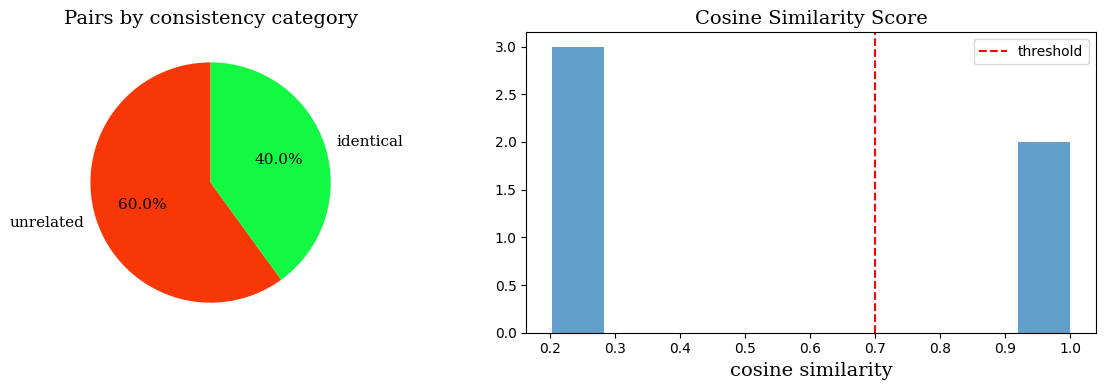

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('Pairs by Consistency Category', fontname='serif', fontsize=14)
axes[0].pie(
    df['consistency_category'].value_counts(), 
    labels=df['consistency_category'].value_counts().index, 
    autopct='%1.1f%%',                         # Displays percentage inside the slices
    startangle=90,                             # Rotates the pie chart for a cleaner look
    colors=['#f93706', '#12f944', '#e9c46a'],  # Keeps your original custom colors
    textprops={'fontsize': 11, 'fontname' : 'serif'}                 # Adjusts the text size inside the chart
)

axes[1].hist(df["pred_cosine_sim"].dropna(), bins=10, alpha=0.7)
axes[1].axvline(bu.CONSISTENCY_COSINE_THRESHOLD, color="red", linestyle="--", label="threshold")
axes[1].set_title("Cosine Similarity Score Distribution", fontname='serif', fontsize=14)
axes[1].set_xlabel("cosine similarity", fontname='serif', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
